<a href="https://colab.research.google.com/github/MohammadJoenathan/Ektraksi-Fitur-Warna-Pada-Citra/blob/main/Mohammad_2218060_Ekstraksi_Fitur_Warna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Menghubungkan Google Colab dengan Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Mengimpor Library Python

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

#Path ke folder gambar di Google Drive

In [ ]:
image_folder = "/content/drive/MyDrive/Colab Notebook/pictures"

# Tampilkan Citra

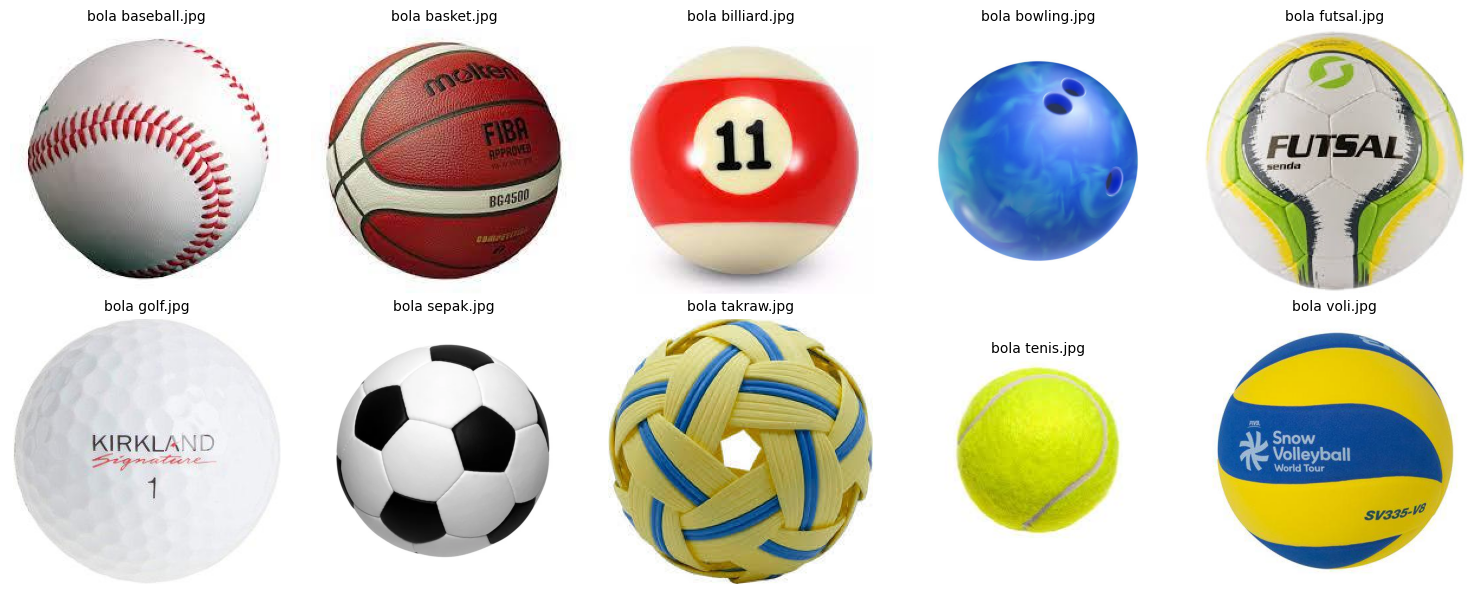

In [ ]:
# List nama file gambar yang digunakan
image_files = ["bola baseball.jpg", "bola basket.jpg", "bola billiard.jpg", "bola bowling.jpg", "bola futsal.jpg",
               "bola golf.jpg", "bola sepak.jpg", "bola takraw.jpg", "bola tenis.jpg", "bola voli.jpg"]

# Menampilkan 10 gambar (2 baris x 5 kolom)
fig, axes = plt.subplots(2, 5, figsize=(15,6))

for i, file in enumerate(image_files):
    img_path = os.path.join(image_folder, file)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i//5, i%5].imshow(img)
    axes[i//5, i%5].set_title(file, fontsize=10)
    axes[i//5, i%5].axis("off")

plt.tight_layout()
plt.show()

#Proses Ekstraksi Fitur Warna Pada Citra

In [ ]:
# Fungsi untuk ekstraksi fitur warna hsv (rata-rata hsv)
def extract_hsv_features(image):
    # Mengubah dari RGB ke HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    # Menghitung rata-rata nilai H, S, dan V
    h = np.mean(hsv[:, :, 0])
    s = np.mean(hsv[:, :, 1])
    v = np.mean(hsv[:, :, 2])
    return h, s, v

# List untuk menyimpan hasil
data = []

# Loop berdasarkan list image_files
for file in image_files:
    # Path gambar
    img_path = os.path.join(image_folder, file)

    # Membaca gambar
    img = cv2.imread(img_path)

    # Cek jika gagal dibaca
    if img is None:
        print(f"Gambar {file} gagal dibaca!")
        continue

    # Convert dari BGR ke RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Ambil fitur HSV
    h, s, v = extract_hsv_features(img_rgb)

    # Simpan ke list
    data.append([file, h, s, v])

# Membuat DataFrame
df_hsv = pd.DataFrame(data, columns=["Nama Gambar", "H", "S", "V"])
# Menampilkan hasil
print(df_hsv)

         Nama Gambar          H           S           V
0  bola baseball.jpg  46.470410   21.011411  211.470509
1    bola basket.jpg  33.604958   87.432731  182.667970
2  bola billiard.jpg  28.162212   81.562686  232.551032
3   bola bowling.jpg  49.072411   77.371041  233.460629
4    bola futsal.jpg  28.596049   47.411931  207.803694
5      bola golf.jpg  81.601902    5.317774  234.548311
6     bola sepak.jpg   1.798540    0.017898  205.073456
7    bola takraw.jpg  35.607526  107.753719  192.556602
8     bola tenis.jpg  19.888353   90.692738  238.963710
9      bola voli.jpg  43.582850  136.039725  214.288238


# Menyimpan hasil ke CSV dan Excel

In [ ]:
# Path penyimpanan
csv_path = "/content/drive/MyDrive/Colab Notebook/Hasil_Ekstraksi/fitur_hsv.csv"
excel_path = "/content/drive/MyDrive/Colab Notebook/Hasil_Ekstraksi/fitur_hsv.xlsx"

# Simpan ke CSV
df_hsv.to_csv(csv_path, index=False)

# Simpan ke Excel
df_hsv.to_excel(excel_path, index=False)